In [3]:
# install + imports + captions + vocab
!pip install torch torchvision nltk tqdm matplotlib  scikit-learn

import os
import re
import pickle
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

IMAGES_DIR = "./Images"
CAPTIONS_FILE = "./captions/Flickr8k.token.txt"

with open(CAPTIONS_FILE, "r") as f:
    lines = f.read().strip().split("\n")

mapping = {}
for line in lines:
    if "\t" not in line:
        continue
    img, caption = line.split("\t")
    img_id = img.split("#")[0]   # npr. 1000268201_693b08cb0e.jpg
    img_id = img_id.strip()
    caption = caption.lower()
    caption = re.sub(r"[^a-z ]", " ", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    caption = "startseq " + caption + " endseq"
    mapping.setdefault(img_id, []).append(caption)

all_captions = [c for caps in mapping.values() for c in caps]
words = set(" ".join(all_captions).split())
word2idx = {w: i+1 for i, w in enumerate(sorted(words))}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(word2idx) + 1
max_length = max(len(c.split()) for c in all_captions)

print("Images with captions:", len(mapping))
print("Vocab size:", vocab_size)
print("Max caption length:", max_length)

image_ids = list(mapping.keys())
random.shuffle(image_ids)
split = int(len(image_ids)*0.9)
train_ids = image_ids[:split]
test_ids = image_ids[split:]

def encode_caption(text):
    return [word2idx[w] for w in text.split() if w in word2idx]


python(28100) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Images with captions: 8092
Vocab size: 8444
Max caption length: 38


In [4]:
# VGG16 feature extraction (-> features.pkl)
features_path = "pt_features.pkl"

if os.path.exists(features_path):
    with open(features_path, "rb") as f:
        features = pickle.load(f)
    print("Loaded features from", features_path)
else:
    vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    vgg.classifier = vgg.classifier[:-1]  # do fc2 -> 4096
    vgg.eval()
    vgg.to(device)

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    features = {}
    for img_id in tqdm(mapping.keys()):
        img_path = os.path.join(IMAGES_DIR, img_id)
        if not os.path.exists(img_path):
            continue
        img = Image.open(img_path).convert("RGB")
        x = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = vgg(x).cpu().numpy()  # shape (1,4096)
        features[img_id] = feat
    with open(features_path, "wb") as f:
        pickle.dump(features, f)
    print("Saved features to", features_path)

print("Feature vectors:", len(features), "dim:", list(features.values())[0].shape)


Loaded features from pt_features.pkl
Feature vectors: 8091 dim: (1, 4096)


In [5]:
# PyTorch Dataset (image feature + input seq + next word)
class FlickrCaptionDataset(Dataset):
    def __init__(self, ids, mapping, features, word2idx, max_length):
        self.samples = []
        self.mapping = mapping
        self.features = features
        self.word2idx = word2idx
        self.max_length = max_length

        for img_id in ids:
            if img_id not in self.features:
                continue
            for caption in mapping[img_id]:
                seq = encode_caption(caption)
                for i in range(1, len(seq)):
                    in_seq = seq[:i]
                    out_word = seq[i]
                    if len(in_seq) > max_length:
                        in_seq = in_seq[-max_length:]
                    pad_len = max_length - len(in_seq)
                    in_seq = ([0]*pad_len) + in_seq
                    self.samples.append((img_id, in_seq, out_word))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, in_seq, out_word = self.samples[idx]
        feat = torch.from_numpy(self.features[img_id].squeeze()).float()
        in_seq = torch.tensor(in_seq, dtype=torch.long)
        out_word = torch.tensor(out_word, dtype=torch.long)
        return feat, in_seq, out_word

from sklearn.model_selection import train_test_split

# svi image ID-evi
all_ids = list(mapping.keys())

# prvo: train (80%) + temp (20%)
train_ids, temp_ids = train_test_split(
    all_ids, test_size=0.20, random_state=42
)

# drugo: od temp napravi val (10%) + test (10%)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50, random_state=42
)

print("Train:", len(train_ids))
print("Val:",   len(val_ids))
print("Test:",  len(test_ids))

train_ds = FlickrCaptionDataset(train_ids, mapping, features, word2idx, max_length)
val_ds   = FlickrCaptionDataset(val_ids,   mapping, features, word2idx, max_length)
test_ds  = FlickrCaptionDataset(test_ids,  mapping, features, word2idx, max_length)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

print("Train samples:", len(train_ds))
print("Val samples:",   len(val_ds))
print("Test samples:",  len(test_ds))



Train: 6473
Val: 809
Test: 810
Train samples: 382566
Val samples: 47640
Test samples: 47678


In [6]:
# CNN+LSTM model (image feat + seq -> next word)
class ImageCaptionModel(nn.Module):
    def __init__(self, feature_dim=4096, embed_dim=256, hidden_dim=256, vocab_size=1, max_length=1):
        super().__init__()
        self.img_fc = nn.Linear(feature_dim, 256)
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim + 256, 256)
        self.fc2 = nn.Linear(256, vocab_size)

    def forward(self, img_feat, seq):
        img_emb = torch.relu(self.img_fc(img_feat))
        emb = self.embed(seq)
        out, _ = self.lstm(emb)
        last = out[:, -1, :]
        x = torch.cat([img_emb, last], dim=1)
        x = torch.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits

model = ImageCaptionModel(
    feature_dim=list(features.values())[0].shape[-1],
    embed_dim=256,
    hidden_dim=256,
    vocab_size=vocab_size,
    max_length=max_length
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Model params:", sum(p.numel() for p in model.parameters()))


Model params: 6038268


In [7]:
# generiranje captiona za jedan image_id
def generate_caption(model, img_id, max_len=max_length):
    model.eval()
    
    # feature za sliku
    feat = torch.from_numpy(features[img_id].squeeze()).float().unsqueeze(0).to(device)
    
    in_text = "startseq"
    for _ in range(max_len):
        seq = encode_caption(in_text)
        if len(seq) > max_len:
            seq = seq[-max_len:]
        pad_len = max_len - len(seq)
        seq = ([0] * pad_len) + seq
        seq = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(feat, seq)
            yhat = logits.argmax(dim=1).item()

        word = idx2word.get(yhat, None)
        if word is None or word == "endseq":
            break

        in_text += " " + word

    return in_text


Starting training...


=========== EPOCH 1/20 ===========



Training: 100%|██████████| 2989/2989 [02:34<00:00, 19.30it/s, loss=3.0918]


Train Loss: 3.6007


Validating: 100%|██████████| 373/373 [00:05<00:00, 70.10it/s, val_loss=3.9160]


Val Loss:   3.2849

BLEU-1:     0.5520
Epoch Time: 168.61s
→ Model saved (best BLEU so far)

=========== EPOCH 2/20 ===========



...

Val Loss:   4.1883

BLEU-1:     0.5574
Epoch Time: 167.03s
→ No BLEU improvement (4/5)

=========== EPOCH 9/20 ===========



Training: 100%|██████████| 2989/2989 [02:33<00:00, 19.44it/s, loss=1.5029]


Train Loss: 1.6679


Validating: 100%|██████████| 373/373 [00:05<00:00, 72.32it/s, val_loss=4.5941]


Val Loss:   4.3604

BLEU-1:     0.5533
Epoch Time: 166.35s
→ No BLEU improvement (5/5)

EARLY STOPPING TRIGGERED (BLEU plateau)!

Training finished.
Best BLEU: 0.6159
Model saved at: models/image_captioning/best_model.pth


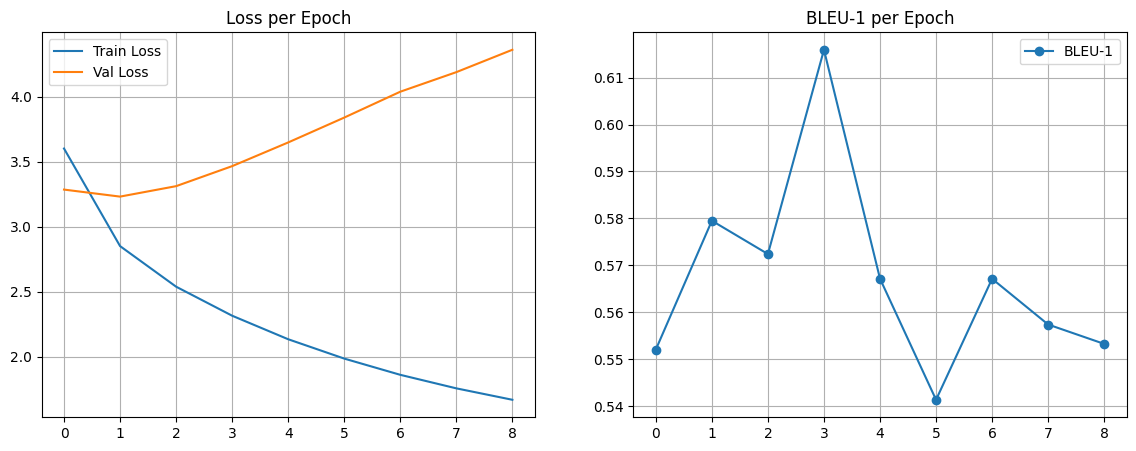

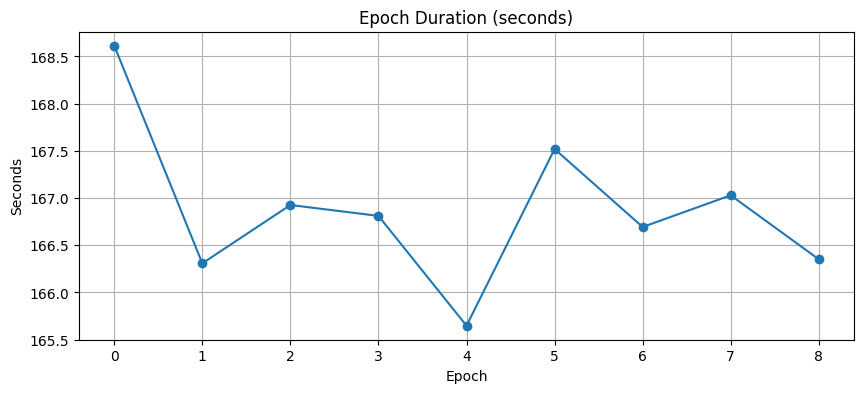

In [30]:
import time
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random
import os
from tqdm import tqdm

cc = SmoothingFunction()
os.makedirs("models/image_captioning", exist_ok=True)

EPOCHS = 20
best_bleu = 0.0
PATIENCE = 5
no_improve = 0

train_losses = []
val_losses = []
bleu_scores = []
epoch_times = []

print("Starting training...\n")

for ep in range(EPOCHS):
    start = time.time()
    model.train()
    train_loss = 0
    steps = 0

    print(f"\n=========== EPOCH {ep+1}/{EPOCHS} ===========\n")

    # ------------------ TRAINING ------------------
    pbar = tqdm(train_loader, desc="Training", leave=True)
    for feat, inp, tgt in pbar:
        feat, inp, tgt = feat.to(device), inp.to(device), tgt.to(device)

        preds = model(feat, inp)
        loss = criterion(preds, tgt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        steps += 1

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train = train_loss / steps
    train_losses.append(avg_train)
    print(f"Train Loss: {avg_train:.4f}")

    # ------------------ VALIDATION LOSS ------------------
    model.eval()
    val_loss = 0
    val_steps = 0

    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc="Validating", leave=True)
        for feat, inp, tgt in pbar_val:
            feat, inp, tgt = feat.to(device), inp.to(device), tgt.to(device)

            preds = model(feat, inp)
            loss = criterion(preds, tgt)

            val_loss += loss.item()
            val_steps += 1

            pbar_val.set_postfix({"val_loss": f"{loss.item():.4f}"})

    avg_val = val_loss / val_steps
    val_losses.append(avg_val)
    print(f"Val Loss:   {avg_val:.4f}")

    # ------------------ VALIDATION BLEU ------------------
    bleu_vals = []
    sample = random.sample(val_ids, min(120, len(val_ids)))

    with torch.no_grad():
        for img_id in sample:
            pred = generate_caption(model, img_id).split()
            refs = [c.split() for c in mapping[img_id]]

            bleu_vals.append(
                sentence_bleu(refs, pred, weights=(1,0,0,0), smoothing_function=cc.method1)
            )

    avg_bleu = sum(bleu_vals) / len(bleu_vals)
    bleu_scores.append(avg_bleu)

    elapsed = time.time() - start
    epoch_times.append(elapsed)

    print(f"\nBLEU-1:     {avg_bleu:.4f}")
    print(f"Epoch Time: {elapsed:.2f}s")

    # ------------------ BEST MODEL + EARLY STOPPING ------------------
    if avg_bleu > best_bleu:
        best_bleu = avg_bleu
        no_improve = 0
        torch.save(model.state_dict(), "models/image_captioning/best_model.pth")
        print("→ Model saved (best BLEU so far)")
    else:
        no_improve += 1
        print(f"→ No BLEU improvement ({no_improve}/{PATIENCE})")

        if no_improve >= PATIENCE:
            print("\nEARLY STOPPING TRIGGERED (BLEU plateau)!")
            break

print("\nTraining finished.")
print(f"Best BLEU: {best_bleu:.4f}")
print("Model saved at: models/image_captioning/best_model.pth")

# --------------------- GRAPHOVI ---------------------

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.grid(True)
plt.title("Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(bleu_scores, marker='o', label="BLEU-1")
plt.legend()
plt.grid(True)
plt.title("BLEU-1 per Epoch")

plt.show()

plt.figure(figsize=(10,4))
plt.plot(epoch_times, marker='o')
plt.grid(True)
plt.title("Epoch Duration (seconds)")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.show()


Original test size: 810
Filtered test size: 809
Loaded best model.

=== RANDOM TEST IMAGE ===
Image: 1346051107_9cdc14e070.jpg

Predicted caption:
startseq a man in a red shirt is standing on a red bench and holding a sword

Ground-truth captions:
 - startseq a man is playing a saxophone next to a fire hydrant endseq
 - startseq a man plays saxophone next to a yellow fire hydrant endseq
 - startseq a man stands by a wall playing a saxophone endseq
 - startseq man playing musical instrument standing beside a yellow and red fire hydrant endseq
 - startseq the man is standing next to a fire hydrant and playing a saxophone endseq


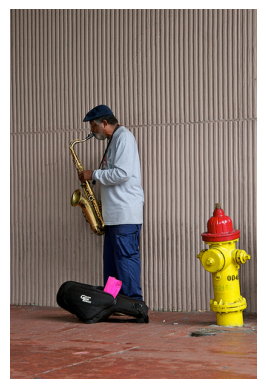

In [18]:
import torch
import random
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from PIL import Image
import matplotlib.pyplot as plt

# ---------------- FILTER TEST IDS ----------------
valid_test_ids = [img_id for img_id in test_ids if img_id in features]
print("Original test size:", len(test_ids))
print("Filtered test size:", len(valid_test_ids))

# ---------------- LOAD BEST MODEL ----------------
best_model = ImageCaptionModel(
    feature_dim=list(features.values())[0].shape[-1],
    embed_dim=256,
    hidden_dim=256,
    vocab_size=vocab_size,
    max_length=max_length
).to(device)

state = torch.load("models/image_captioning/best_model.pth", map_location=device)
best_model.load_state_dict(state)
best_model.eval()

print("Loaded best model.")


# ---------------- SHOW RANDOM TEST IMAGE ----------------
def show_random_test_prediction():
    img_id = random.choice(valid_test_ids)
    img_path = f"{IMAGES_DIR}/{img_id}"

    # load image
    img = Image.open(img_path).convert("RGB")

    # predicted caption
    pred = generate_caption(best_model, img_id)

    # ground truth (5 captions)
    gt_captions = mapping[img_id]

    print("\n=== RANDOM TEST IMAGE ===")
    print("Image:", img_id)
    print("\nPredicted caption:")
    print(pred)

    print("\nGround-truth captions:")
    for c in gt_captions:
        print(" -", c)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_random_test_prediction()



In [36]:
# ---------------- BLEU ON FULL TEST SET ----------------

print("\nComputing BLEU on filtered test set...")

smooth = SmoothingFunction().method1
actual, predicted = [], []

for img_id in valid_test_ids:
    pred = generate_caption(best_model, img_id).split()
    refs = [c.split() for c in mapping[img_id]]

    predicted.append(pred)
    actual.append(refs)

bleu1 = corpus_bleu(actual, predicted, weights=(1,0,0,0), smoothing_function=smooth)
bleu2 = corpus_bleu(actual, predicted, weights=(0.5,0.5,0.5,0), smoothing_function=smooth)

print("\n=== BLEU RESULTS ===")
print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")


Computing BLEU on filtered test set...

=== BLEU RESULTS ===
BLEU-1: 0.5698
BLEU-2: 0.1427


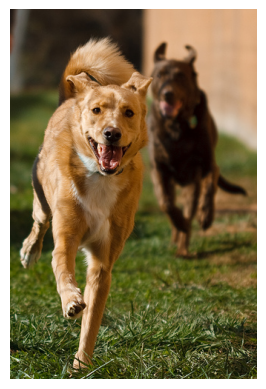

Slika: 3106883334_419f3fb16f.jpg

Captioni:
- A dark brown dog runs behind a yellow dog in the grass .
- one tan dog running on the grass with a brown dog running close behind
- The two dogs , one dark and one light colored , are running outdoors .
- Two brown dogs are running through a grassy area .
- Two dogs run over the grass .


In [9]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# put do slike i caption datoteke
image_folder = "Images"
caption_file = "captions/Flickr8k.token.txt"

# učitaj sve captione
captions = open(caption_file, 'r').read().strip().split('\n')

# odaberi random sliku
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# filtriraj samo captione koji pripadaju toj slici
image_captions = [c.split('\t')[1] for c in captions if image_name in c]

# prikaži sliku
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

# ispiši captione
print("Slika:", image_name)
print("\nCaptioni:")
for c in image_captions:
    print("-", c)
